<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula03b%20regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

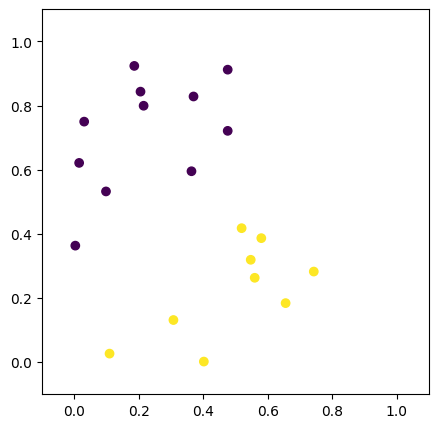

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, coef=0.5, intercept=0.2):
  X = np.random.rand(n,20)
  y = np.array(X[:,0]*coef>(X[:,1]-intercept), dtype=int)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

plotDataset(X, y)
plt.show()

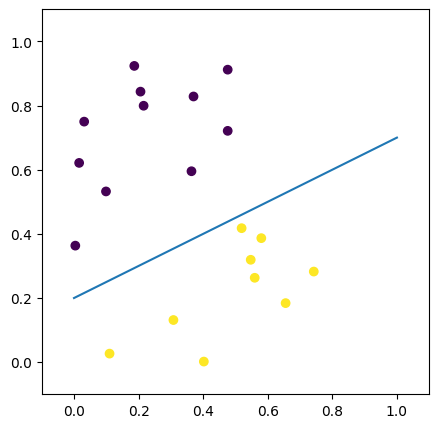

In [48]:
def plotHyperplan(vector, intercept=0):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, '-')

plotDataset(X, y)
plotHyperplan(np.array([0.5,-1]), 0.2)
plt.show()


In [49]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

In [54]:
from abc import ABC, abstractstaticmethod

class Cost(ABC):
  @abstractstaticmethod
  def getCost(y, ypred):
    pass
  @abstractstaticmethod
  def getGradient(y, ypred, X):
    pass

class WidrowHoff(Cost):
  @staticmethod
  def getCost(y, ypred):
    return 0.5* ((y-ypred)**2)
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y-ypred)

class SmoothedSurrogate(Cost):
  @staticmethod
  def getCost(y, ypred):
    return np.sum(np.maximum(np.zeros(y.shape), -y * ypred))
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y - sign(ypred))

from numpy import tanh
class LogLikehood(Cost):
  @staticmethod
  def getCost(y, ypred):
    return np.sum(np.maximum(np.zeros(y.shape), 1 - y * ypred))
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y - tanh(ypred))

class HingeLoss(Cost):
  @staticmethod
  def getCost(y, ypred):
    return np.sum(np.maximum(np.zeros(y.shape), 1 - y * ypred))
  @staticmethod
  def getGradient(y, ypred, X):
    marginal_errors = (y * ypred) < 0.1
    marginal_ys = np.copy(y)
    marginal_ys[~marginal_errors] = 0
    return X.T @ marginal_ys

In [5]:
from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class GradientDescent(TrainingAlgorithm):
  def __init__(self, learning_rate=0.005, n_iter=500, cost=WidrowHoff()):
    self.learning_rate = learning_rate
    self.n_iter = n_iter
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=X.shape[1])*2-1
    for _ in range(self.n_iter):
      ypred = X @ w
      w += self.learning_rate * self.cost.getGradient(y, ypred, X)
    return w

In [51]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm=GradientDescent()):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = self.trainingAlgorithm.getW(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    return np.sign(X @ self.w_)



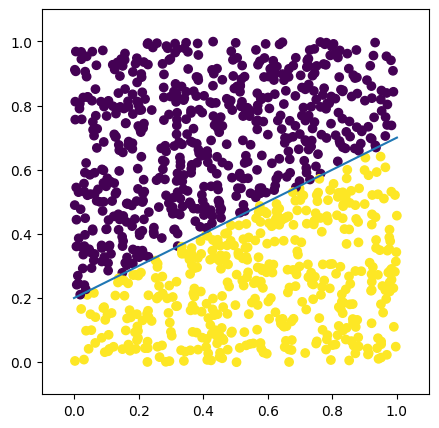

In [55]:
X_test, y_test = createDataset(n=1000)
plotDataset(X_test, y_test)
plotHyperplan(np.array([0.5,-1]), 0.2)
plt.show()

Cost Function: <class '__main__.WidrowHoff'>
Accuracy: 1.0
Weights: [-0.77892428  1.77961682 -2.03309228 -0.26896561 -0.09406816  0.28879613
  1.09628907  1.23851945 -1.00308145  0.05404296 -0.49498857 -0.33129698
 -0.06081073 -0.08442279  0.13705836  0.01494784  0.51092891  0.08657944
  0.19791601  0.80175417  0.17490272]


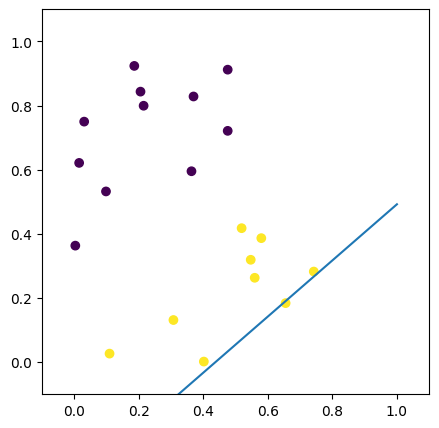

Test Accuracy: 0.741


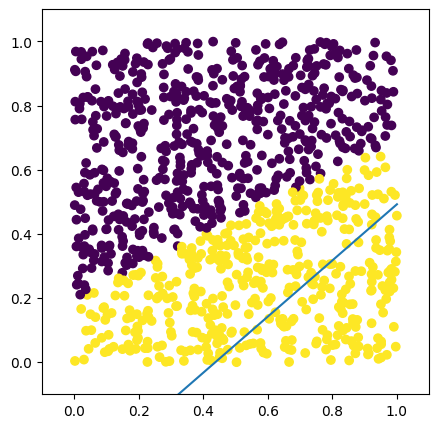

Cost Function: <class '__main__.SmoothedSurrogate'>
Accuracy: 1.0
Weights: [ 0.21999774  0.71138129 -0.02438979 -0.18427301  0.29439669 -0.32642209
  0.37044904 -0.85001885  0.49219092 -0.47887689 -0.12899725 -0.57112654
  0.44993562  0.75349827 -0.22780174 -0.1804187   0.47020747 -0.092148
 -0.10905011 -0.104317   -0.21825923]


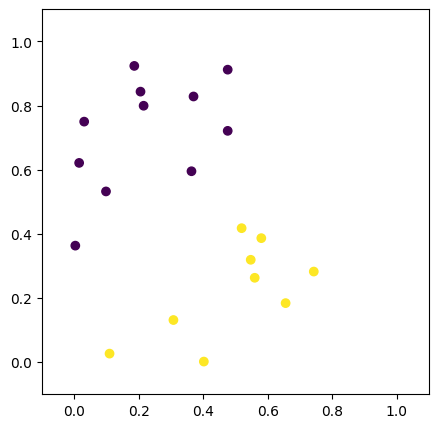

Test Accuracy: 0.539


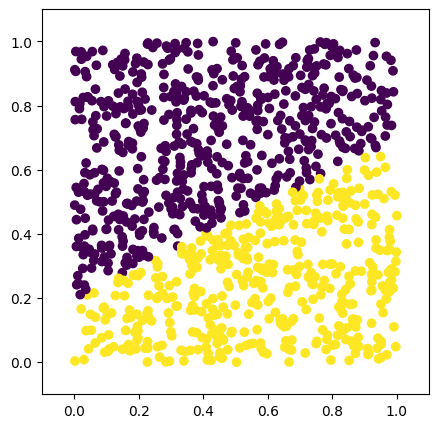

Cost Function: <class '__main__.LogLikehood'>
Accuracy: 1.0
Weights: [-1.33509648  1.48566281 -3.10998794  0.16162642  0.64229476 -0.14589729
  1.3484163   0.75940204 -0.33870854 -0.15839374  0.12039281  0.19355785
  1.37193661  0.519173    0.04554993  0.20667771  1.02844497 -0.89500929
 -0.46696885  0.40239571 -0.1230643 ]


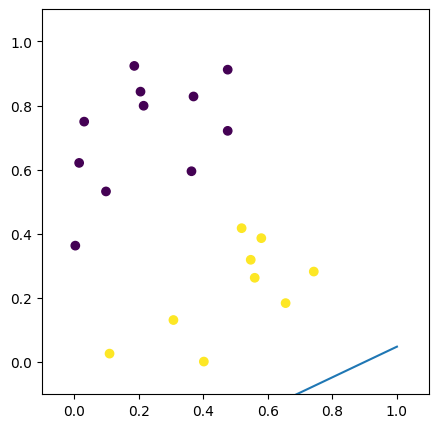

Test Accuracy: 0.786


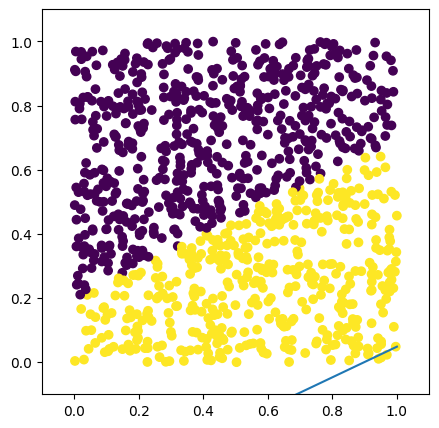

Cost Function: <class '__main__.HingeLoss'>
Accuracy: 1.0
Weights: [ 0.46843859  0.4700519  -1.23544041  0.0213608   0.77549406  0.08504481
 -0.49682122 -0.16197741 -0.3601832  -0.55617098 -0.08855078 -0.85072748
 -0.28126748  0.89385028 -0.30303705  0.54542587 -0.65100041 -0.34220422
  0.23922763  0.64478842  0.54156523]


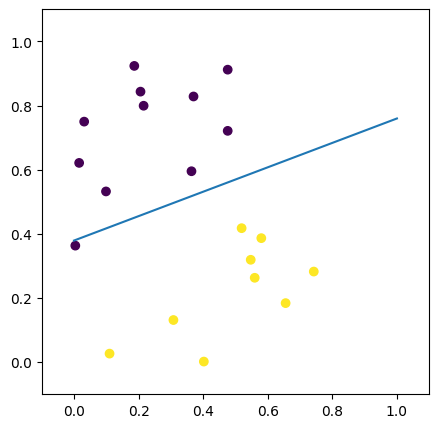

Test Accuracy: 0.678


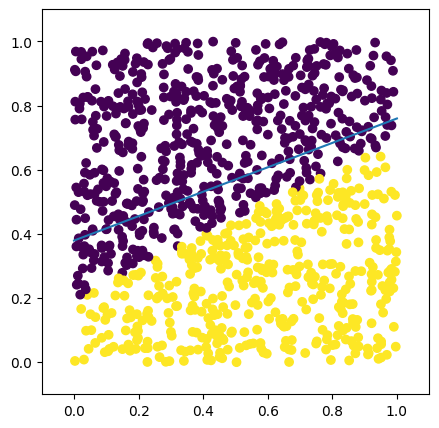

In [57]:
cost_functions = [WidrowHoff, SmoothedSurrogate, LogLikehood, HingeLoss]

for cost in cost_functions:
  model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=cost()))
  model.fit(X, y)
  ypred = model.predict(X)
  print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
  print(f"Accuracy: {accuracy_score(y, ypred)}")
  print(f"Weights: {model.w_}")
  plotDataset(X, y)
  plotHyperplan(model.w_[1:], model.w_[0])
  plt.show()
  ypred_test = model.predict(X_test)
  print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")
  plotDataset(X_test, y_test)
  plotHyperplan(model.w_[1:], model.w_[0])
  plt.show()

In [58]:
class GradientDescent(TrainingAlgorithm):
  def __init__(self, learning_rate=0.005, n_iter=500,
               regularization = 0,
               cost=WidrowHoff()):
    self.learning_rate = learning_rate
    self.n_iter = n_iter
    self.regularization = regularization
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=X.shape[1])*2-1
    for _ in range(self.n_iter):
      ypred = X @ w
      w *= (1-self.learning_rate*self.regularization)
      w += self.learning_rate * self.cost.getGradient(y, ypred, X)
    return w

In [77]:
model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=WidrowHoff(),
                                                        regularization=2))
model.fit(X, y)
ypred = model.predict(X)
print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
print(f"Train Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {model.w_}")
ypred_test = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")

Cost Function: <class '__main__.WidrowHoff'>
Train Accuracy: 1.0
Weights: [-0.15612947  0.5015558  -1.0519876   0.02042731  0.25352448 -0.0755005
  0.3442355   0.25138505 -0.0915276  -0.19466019  0.11717475  0.05746192
  0.32433186  0.21619366 -0.08071197 -0.00151271  0.19283354 -0.34185465
 -0.15320453  0.11835596  0.00387786]
Test Accuracy: 0.815


In [98]:
model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=SmoothedSurrogate(),
                                                        regularization=2))
model.fit(X, y)
ypred = model.predict(X)
print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
print(f"Train Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {model.w_}")
ypred_test = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")

Cost Function: <class '__main__.SmoothedSurrogate'>
Train Accuracy: 1.0
Weights: [ 0.00052322  0.00679393 -0.00472631 -0.00149203 -0.00045149  0.00076932
  0.00172359  0.00625113 -0.00191818 -0.00247936  0.00257869  0.00315648
 -0.00254513  0.00085132 -0.00056604 -0.00377563 -0.00206904 -0.00093331
  0.00233468  0.00069318 -0.00422523]
Test Accuracy: 0.676


In [105]:
model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=LogLikehood(),
                                                        regularization=2))
model.fit(X, y)
ypred = model.predict(X)
print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
print(f"Train Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {model.w_}")
ypred_test = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")

Cost Function: <class '__main__.LogLikehood'>
Train Accuracy: 1.0
Weights: [-0.17829012  0.5434543  -1.13088803 -0.00661215  0.27990815 -0.08860539
  0.39280025  0.26380323 -0.10313509 -0.23046397  0.15098264  0.09512445
  0.3550775   0.25105979 -0.11398784 -0.01994325  0.22369959 -0.40830315
 -0.19599483  0.11344001  0.02773251]
Test Accuracy: 0.812


In [109]:
model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=HingeLoss(),
                                                        regularization=2))
model.fit(X, y)
ypred = model.predict(X)
print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
print(f"Train Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {model.w_}")
ypred_test = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")

Cost Function: <class '__main__.HingeLoss'>
Train Accuracy: 1.0
Weights: [-6.76144128e-02  1.87186790e-01 -3.67639860e-01  3.77353245e-02
  8.46999909e-02 -2.37095163e-02  9.37278130e-02  8.83743600e-02
 -3.10306959e-02 -7.76961078e-02 -3.48011555e-04  6.34043048e-03
  1.14454888e-01  6.39142006e-02 -2.01861302e-02 -1.84117248e-02
  4.64638886e-02 -9.60971246e-02 -4.24205217e-02  7.61690144e-02
 -1.69306673e-02]
Test Accuracy: 0.844


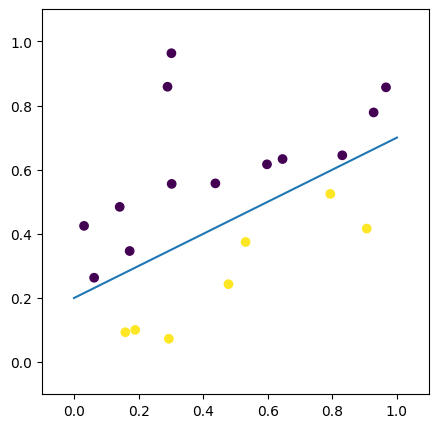

In [110]:
X, y = createDataset()
plotDataset(X, y)
plotHyperplan(np.array([0.5,-1]), 0.2)
plt.show()

In [118]:
cost_functions = [WidrowHoff, SmoothedSurrogate, LogLikehood, HingeLoss]

for cost in cost_functions:
  model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=cost(),
                                                          n_iter=1000))
  model.fit(X, y)
  ypred = model.predict(X)
  print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
  print(f"Accuracy: {accuracy_score(y, ypred)}")
  print(f"Weights: {model.w_}")
  ypred_test = model.predict(X_test)
  print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")


Cost Function: <class '__main__.WidrowHoff'>
Accuracy: 1.0
Weights: [-0.47866612  0.67808048 -2.83414694 -0.26726156  1.57773184  0.72119026
  0.3503344  -0.64237303  0.76410313 -0.5214429  -0.48667937  0.20233841
 -1.4361878   0.64337275  0.14342034 -0.2618209   0.49958461  0.20347705
 -0.6199682   0.82707721  0.55421545]
Test Accuracy: 0.767
Cost Function: <class '__main__.SmoothedSurrogate'>
Accuracy: 1.0
Weights: [-0.35009033  0.76978462 -0.98413072 -0.2122586   0.67380605 -0.15050891
  0.99711767 -0.92045292 -0.67365109  0.19475351  0.81236008  0.49754349
 -0.37471639  0.17396757  0.46314572 -0.6367508   0.38431123 -0.81934514
  0.36266273 -0.07735829 -0.02416343]
Test Accuracy: 0.667
Cost Function: <class '__main__.LogLikehood'>
Accuracy: 1.0
Weights: [-1.00369963  1.36287653 -4.18862266 -0.69237395  2.65000587 -0.03869561
  1.34406305 -0.63784467  0.49701793 -0.42427219 -0.49902282  0.20593923
 -2.15225992  0.60377644  0.3207483   0.03756785  0.11689541 -0.34277521
 -0.63197359 

In [121]:
cost_functions = [WidrowHoff, SmoothedSurrogate, LogLikehood, HingeLoss]

for cost in cost_functions:
  model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=cost(),
                                                          n_iter=1000,
                                                          regularization=1))
  model.fit(X, y)
  ypred = model.predict(X)
  print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
  print(f"Accuracy: {accuracy_score(y, ypred)}")
  print(f"Weights: {model.w_}")
  ypred_test = model.predict(X_test)
  print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")

Cost Function: <class '__main__.WidrowHoff'>
Accuracy: 1.0
Weights: [-0.18531867  0.21946584 -1.42468622 -0.19914124  0.70672907  0.11864899
  0.3375353  -0.27146247  0.14323361 -0.30385033 -0.17810536  0.26787124
 -0.6494637   0.15934851  0.18398144 -0.07029313  0.16181677 -0.15822143
 -0.24950213  0.31365259  0.48079151]
Test Accuracy: 0.748
Cost Function: <class '__main__.SmoothedSurrogate'>
Accuracy: 1.0
Weights: [ 0.00137975  0.00192651 -0.00626745 -0.00166578  0.00382308  0.0019686
 -0.00038864 -0.00371298  0.00112553  0.00043756 -0.00294404 -0.00306381
 -0.00479098 -0.00038599  0.00378337  0.00133827 -0.00180508 -0.00286933
 -0.00048807  0.00338256  0.00337718]
Test Accuracy: 0.683
Cost Function: <class '__main__.LogLikehood'>
Accuracy: 1.0
Weights: [-0.2105061   0.24630262 -1.5649612  -0.30058658  0.75565231  0.06672763
  0.47048176 -0.25142088  0.05987282 -0.2977726  -0.13778291  0.25420906
 -0.75147336  0.13480339  0.28200542 -0.0582323   0.09412898 -0.22475964
 -0.21018373  

In [122]:
cost_functions = [WidrowHoff, SmoothedSurrogate, LogLikehood, HingeLoss]

for cost in cost_functions:
  model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=cost(),
                                                          n_iter=1000,
                                                          regularization=2))
  model.fit(X, y)
  ypred = model.predict(X)
  print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
  print(f"Accuracy: {accuracy_score(y, ypred)}")
  print(f"Weights: {model.w_}")
  ypred_test = model.predict(X_test)
  print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")


Cost Function: <class '__main__.WidrowHoff'>
Accuracy: 1.0
Weights: [-0.14826357  0.12372402 -0.97747064 -0.17369508  0.45388924  0.03315356
  0.2765528  -0.17525123  0.02738851 -0.19152867 -0.11360271  0.17657013
 -0.4614494   0.0994392   0.17124714 -0.03699613  0.08508858 -0.1623077
 -0.14026484  0.20215823  0.35274177]
Test Accuracy: 0.717
Cost Function: <class '__main__.SmoothedSurrogate'>
Accuracy: 1.0
Weights: [ 2.48019290e-05  3.42599445e-05 -4.35920292e-05 -1.99558977e-05
  1.61096124e-05 -5.38362739e-06  2.59326922e-05 -8.12647866e-06
  1.30388154e-05 -1.98874981e-05 -1.18423112e-05  2.70898218e-05
 -2.39061677e-05  9.40451953e-06 -8.19321459e-06 -1.71002992e-06
  6.02491526e-06 -3.40017889e-05 -1.52789676e-06 -1.46015591e-05
 -1.40674518e-05]
Test Accuracy: 0.715
Cost Function: <class '__main__.LogLikehood'>
Accuracy: 1.0
Weights: [-0.15726893  0.1341894  -1.03322742 -0.21586862  0.46533846  0.009688
  0.32597222 -0.16093406 -0.00730311 -0.19016895 -0.09762641  0.16459118
 -0

In [123]:
cost_functions = [WidrowHoff, SmoothedSurrogate, LogLikehood, HingeLoss]

for cost in cost_functions:
  model = NeuralNetwork(trainingAlgorithm=GradientDescent(cost=cost(),
                                                          n_iter=1000,
                                                          regularization=5))
  model.fit(X, y)
  ypred = model.predict(X)
  print(f"Cost Function: {model.trainingAlgorithm.cost.__class__}")
  print(f"Accuracy: {accuracy_score(y, ypred)}")
  print(f"Weights: {model.w_}")
  ypred_test = model.predict(X_test)
  print(f"Test Accuracy: {accuracy_score(y_test, ypred_test)}")

Cost Function: <class '__main__.WidrowHoff'>
Accuracy: 0.8
Weights: [-0.0996003   0.04481216 -0.52497603 -0.12356827  0.20796817 -0.01776414
  0.1649988  -0.08729676 -0.03172981 -0.0952825  -0.06175668  0.07596339
 -0.26701858  0.04225683  0.11682915 -0.01902114  0.02222782 -0.11892077
 -0.05774193  0.09157644  0.19249583]
Test Accuracy: 0.633
Cost Function: <class '__main__.SmoothedSurrogate'>
Accuracy: 1.0
Weights: [ 4.06399168e-13  1.23716612e-12 -2.14890094e-11 -2.18804609e-12
  6.54942606e-12 -8.84245518e-12  8.59052017e-12 -2.96957000e-12
 -2.03050863e-12 -5.13356950e-12  4.65695817e-12  8.16697515e-12
 -3.81270119e-12 -8.45325245e-12  5.71007616e-12  2.21378787e-12
  1.71370722e-12  9.00313090e-13 -9.47221658e-12 -4.92160722e-12
  1.07602958e-11]
Test Accuracy: 0.672
Cost Function: <class '__main__.LogLikehood'>
Accuracy: 0.8
Weights: [-0.10280619  0.04577311 -0.53823007 -0.13366855  0.20919705 -0.02368795
  0.17483026 -0.08341271 -0.04025338 -0.09633645 -0.05937117  0.07196569
